In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Optional: cleaner academic-style charts
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
print("Loading historical and predicted data (this may take a few moments)...")

# 1) HISTORICAL: load timestamp + OD to align the comparison with forecast coverage
df_hist = pd.read_csv(
    'data/Data_2019-2023.csv',
    usecols=['Trip Start Timestamp', 'Pickup Census Tract', 'Dropoff Census Tract']
 )
df_hist['Number of Trips'] = 1

# 2) PREDICTED: model output file (semicolon separator)
df_pred = pd.read_csv(
    'data/predicted_observations.csv',
    sep=';',
    usecols=['Trip Start Timestamp', 'Pickup Census Tract', 'Dropoff Census Tract', 'Number of Trips']
 )

print(f"Total historical trips: {len(df_hist):,} | Predicted OD-hour rows: {len(df_pred):,}")

Loading historical and predicted data (this may take a few moments)...
Total historical trips: 5,984,439 | Predicted OD-hour rows: 125,100


In [3]:
print("Processing timestamps...")

# Robust timestamp parsing
df_hist['Trip Start Timestamp'] = pd.to_datetime(df_hist['Trip Start Timestamp'], format='mixed', errors='coerce')
df_pred['Trip Start Timestamp'] = pd.to_datetime(df_pred['Trip Start Timestamp'], format='mixed', errors='coerce')

# Drop rows with invalid timestamps
df_hist = df_hist.dropna(subset=['Trip Start Timestamp']).copy()
df_pred = df_pred.dropna(subset=['Trip Start Timestamp']).copy()

# Time features
df_hist['Date'] = df_hist['Trip Start Timestamp'].dt.date
df_hist['Hour'] = df_hist['Trip Start Timestamp'].dt.hour
df_pred['Date'] = df_pred['Trip Start Timestamp'].dt.date
df_pred['Hour'] = df_pred['Trip Start Timestamp'].dt.hour

Processing timestamps...


In [4]:
# Restrict analysis to valid forecast hours (08:00-20:00)
valid_hours = list(range(8, 21))

# Align historical data to the same forecast coverage: same hours and same OD tracts
pred_pickups = set(df_pred['Pickup Census Tract'].unique())
pred_dropoffs = set(df_pred['Dropoff Census Tract'].unique())

hist_aligned = df_hist[
    df_hist['Hour'].isin(valid_hours)
    & df_hist['Pickup Census Tract'].isin(pred_pickups)
    & df_hist['Dropoff Census Tract'].isin(pred_dropoffs)
]
pred_aligned = df_pred[df_pred['Hour'].isin(valid_hours)]

# Total trips for each hour in each day
hist_daily = hist_aligned.groupby(['Date', 'Hour'])['Number of Trips'].sum().reset_index()
pred_daily = pred_aligned.groupby(['Date', 'Hour'])['Number of Trips'].sum().reset_index()

# Average daily trips by hour
hist_mean = hist_daily.groupby('Hour')['Number of Trips'].mean().reindex(valid_hours, fill_value=0).reset_index()
pred_mean = pred_daily.groupby('Hour')['Number of Trips'].mean().reindex(valid_hours, fill_value=0).reset_index()

print("Aggregated data is ready for plotting (aligned comparison, 08:00-20:00).")
print(f"Valid plotted hours: {valid_hours[0]}-{valid_hours[-1]}")
print(f"Historical rows after OD+hour alignment: {len(hist_aligned):,}")

Aggregated data is ready for plotting (aligned comparison, 08:00-20:00).
Valid plotted hours: 8-20
Historical rows after OD+hour alignment: 1,776,381


✅ Plot generated and saved to: plots/hourly_demand_comparison.png


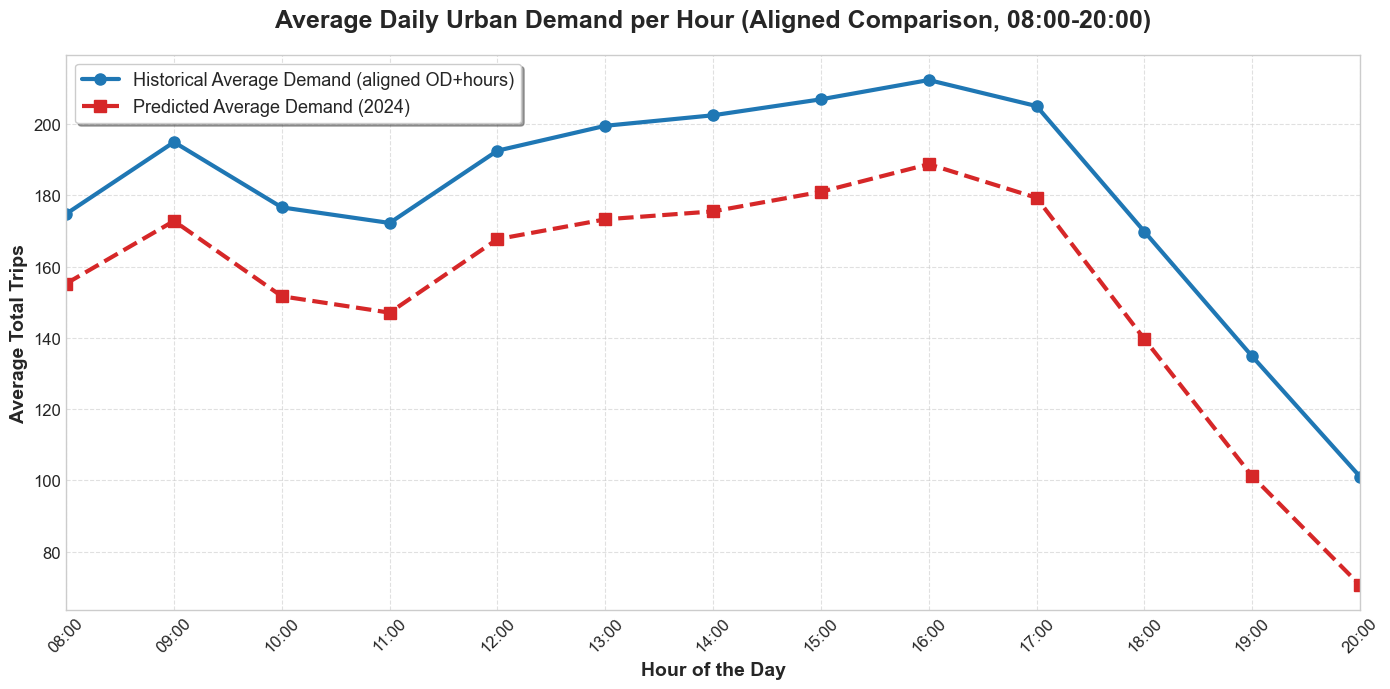

In [5]:
plt.figure(figsize=(14, 7))

# Aligned historical curve (blue)
plt.plot(hist_mean['Hour'], hist_mean['Number of Trips'],
         marker='o', markersize=8, linewidth=3,
         label='Historical Average Demand (aligned OD+hours)', color='#1f77b4')

# Predicted curve (red dashed)
plt.plot(pred_mean['Hour'], pred_mean['Number of Trips'],
         marker='s', markersize=8, linewidth=3, linestyle='--',
         label='Predicted Average Demand (2024)', color='#d62728')

# Titles and labels
plt.title('Average Daily Urban Demand per Hour (Aligned Comparison, 08:00-20:00)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Hour of the Day', fontsize=14, fontweight='bold')
plt.ylabel('Average Total Trips', fontsize=14, fontweight='bold')

# X-axis limited to valid forecast hours
plt.xlim(8, 20)
plt.xticks(range(8, 21), [f"{h:02d}:00" for h in range(8, 21)], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=13, loc='upper left', frameon=True, shadow=True)
plt.tight_layout()

# Save plot
os.makedirs('plots', exist_ok=True)
plot_path = 'plots/hourly_demand_comparison.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

print(f"✅ Plot generated and saved to: {plot_path}")
plt.show()

## Presentation-ready results

> The cells below add compact metrics and two map-style views to compare historical demand vs 2024 predictions.

> Note: the interactive map uses **synthetic zone coordinates** (no geospatial shapefile is available in the project), so it is a visual comparison map, not a true geographic map.

In [6]:
import numpy as np
from IPython.display import display

# --- KPI table: Community Areas + OD support aligned ---
# Goal: compare historical vs predicted demand only where predictions actually exist
# and on the same OD support to avoid artificial -100% from uncovered areas.

# 1) OD support present in predictions
pred_pickups = set(pred_aligned['Pickup Census Tract'].dropna().unique())
pred_dropoffs = set(pred_aligned['Dropoff Census Tract'].dropna().unique())

# 2) Align historical rows to the same OD support used by predictions
hist_od_aligned = hist_aligned[
    hist_aligned['Pickup Census Tract'].isin(pred_pickups)
    & hist_aligned['Dropoff Census Tract'].isin(pred_dropoffs)
].copy()

# 3) Build pickup census tract -> community area map from historical source
hist_ca_index = pd.read_csv(
    'data/Data_2019-2023.csv',
    usecols=['Pickup Census Tract', 'Pickup Community Area']
)
hist_ca_index['Pickup Census Tract'] = pd.to_numeric(
    hist_ca_index['Pickup Census Tract'], errors='coerce'
).astype('Int64')

pickup_ca_map = (
    hist_ca_index.dropna(subset=['Pickup Census Tract', 'Pickup Community Area'])
    .groupby('Pickup Census Tract')['Pickup Community Area']
    .agg(lambda s: s.mode().iloc[0])
)

# 4) Map both aligned datasets to community areas
hist_od_aligned['Pickup Community Area'] = pd.to_numeric(
    hist_od_aligned['Pickup Census Tract'], errors='coerce'
).astype('Int64').map(pickup_ca_map)

pred_ca_aligned = pred_aligned.copy()
pred_ca_aligned['Pickup Community Area'] = pd.to_numeric(
    pred_ca_aligned['Pickup Census Tract'], errors='coerce'
).astype('Int64').map(pickup_ca_map)

# Keep only mapped rows
hist_od_aligned = hist_od_aligned.dropna(subset=['Pickup Community Area']).copy()
pred_ca_aligned = pred_ca_aligned.dropna(subset=['Pickup Community Area']).copy()

# 5) Keep only community areas covered by predictions
covered_cas = sorted(pred_ca_aligned['Pickup Community Area'].unique())
hist_ca_cov = hist_od_aligned[hist_od_aligned['Pickup Community Area'].isin(covered_cas)].copy()
pred_ca_cov = pred_ca_aligned[pred_ca_aligned['Pickup Community Area'].isin(covered_cas)].copy()

# 6) CA-level average daily pickups (08:00-20:00 already enforced upstream)
hist_ca_daily = (
    hist_ca_cov.groupby(['Date', 'Pickup Community Area'])['Number of Trips']
    .sum()
    .groupby('Pickup Community Area')
    .mean()
)
pred_ca_daily = (
    pred_ca_cov.groupby(['Date', 'Pickup Community Area'])['Number of Trips']
    .sum()
    .groupby('Pickup Community Area')
    .mean()
)

ca_kpi = pd.concat([
    hist_ca_daily.rename('hist_daily_avg'),
    pred_ca_daily.rename('pred_daily_avg')
], axis=1).fillna(0)

ca_kpi['abs_gap'] = (ca_kpi['pred_daily_avg'] - ca_kpi['hist_daily_avg']).abs()
ca_kpi['pct_error'] = (
    100.0 * ca_kpi['abs_gap'] / (ca_kpi['hist_daily_avg'] + 1e-9)
)
ca_kpi = ca_kpi.sort_values('hist_daily_avg', ascending=False)

# 7) Global aligned KPIs
hist_total_daily = hist_ca_cov.groupby('Date')['Number of Trips'].sum()
pred_total_daily = pred_ca_cov.groupby('Date')['Number of Trips'].sum()

kpi_aligned = pd.DataFrame({
    'Metric': [
        'Covered community areas (count)',
        'Avg daily demand (historical, OD+CA aligned)',
        'Avg daily demand (predicted, OD+CA aligned)',
        'Total demand (historical, OD+CA aligned)',
        'Total demand (predicted, OD+CA aligned)',
        'Mean CA absolute daily gap',
        'Mean CA pct error (%)'
    ],
    'Value': [
        len(covered_cas),
        hist_total_daily.mean(),
        pred_total_daily.mean(),
        hist_ca_cov['Number of Trips'].sum(),
        pred_ca_cov['Number of Trips'].sum(),
        ca_kpi['abs_gap'].mean(),
        ca_kpi['pct_error'].mean()
    ]
})

print('Aligned CA KPI summary (same OD support + covered community areas only)')
display(kpi_aligned.style.format({'Value': '{:,.2f}'}))

print('Top covered community areas by historical aligned demand')
display(ca_kpi.head(10).style.format({
    'hist_daily_avg': '{:,.2f}',
    'pred_daily_avg': '{:,.2f}',
    'abs_gap': '{:,.2f}',
    'pct_error': '{:,.2f}'
}))

print(f'Coverage debug -> CAs covered: {len(covered_cas)} | OD-aligned historical rows: {len(hist_od_aligned):,} | Pred rows: {len(pred_ca_aligned):,}')

Aligned CA KPI summary (same OD support + covered community areas only)


,Metric,Value
0,Covered community areas (count),5.00
1,"Avg daily demand (historical, OD+CA aligned)","2,334.27"
2,"Avg daily demand (predicted, OD+CA aligned)","2,003.82"
3,"Total demand (historical, OD+CA aligned)","1,776,381.00"
4,"Total demand (predicted, OD+CA aligned)","733,398.00"
5,Mean CA absolute daily gap,66.97
6,Mean CA pct error (%),18.68


Top covered community areas by historical aligned demand


,hist_daily_avg,pred_daily_avg,abs_gap,pct_error
Pickup Community Area,,,,
32.000000,913.40,792.98,120.42,13.18
76.000000,587.68,575.06,12.61,2.15
8.000000,396.20,300.63,95.57,24.12
28.000000,285.18,236.76,48.42,16.98
33.000000,156.51,98.66,57.85,36.96


Coverage debug -> CAs covered: 5 | OD-aligned historical rows: 1,776,381 | Pred rows: 125,100


## Real-zone reconstruction from historical centroids

> This map rebuilds zone coordinates from historical `POINT (lon lat)` centroid fields and compares predicted vs historical pickup demand using real coordinates.

In [7]:
import re
import folium

# --- Community-area map on ALIGNED support only ---
# Goal: show model error only where predictions are actually defined.

# STEP A) Build reusable index from historical data:
#         Census Tract -> Community Area + Community Area -> centroid (lat, lon)
hist_index_src = pd.read_csv(
    'data/Data_2019-2023.csv',
    usecols=[
        'Trip Start Timestamp',
        'Pickup Census Tract', 'Dropoff Census Tract',
        'Pickup Community Area', 'Dropoff Community Area',
        'Pickup Centroid Location', 'Dropoff Centroid  Location'
    ]
)

point_pattern = re.compile(r'POINT \(([-0-9\.]+) ([-0-9\.]+)\)')

def parse_point(point_text):
    if pd.isna(point_text):
        return (np.nan, np.nan)
    m = point_pattern.search(str(point_text))
    if not m:
        return (np.nan, np.nan)
    lon = float(m.group(1))
    lat = float(m.group(2))
    return (lat, lon)

# Parse historical timestamps + hour/date
hist_index_src['Trip Start Timestamp'] = pd.to_datetime(
    hist_index_src['Trip Start Timestamp'], format='mixed', errors='coerce'
)
hist_index_src = hist_index_src.dropna(subset=['Trip Start Timestamp']).copy()
hist_index_src['Date'] = hist_index_src['Trip Start Timestamp'].dt.date
hist_index_src['Hour'] = hist_index_src['Trip Start Timestamp'].dt.hour
hist_index_src['Number of Trips'] = 1

# Build Census Tract -> Community Area mapping (mode)
pickup_map = (
    hist_index_src.dropna(subset=['Pickup Census Tract', 'Pickup Community Area'])
    .groupby('Pickup Census Tract')['Pickup Community Area']
    .agg(lambda s: s.mode().iloc[0])
)
dropoff_map = (
    hist_index_src.dropna(subset=['Dropoff Census Tract', 'Dropoff Community Area'])
    .groupby('Dropoff Census Tract')['Dropoff Community Area']
    .agg(lambda s: s.mode().iloc[0])
)

# Build Community Area centroid candidates from both pickup and dropoff points
pickup_latlon = hist_index_src['Pickup Centroid Location'].apply(parse_point)
dropoff_latlon = hist_index_src['Dropoff Centroid  Location'].apply(parse_point)

pickup_ca_coords = pd.DataFrame({
    'community_area': hist_index_src['Pickup Community Area'],
    'lat': pickup_latlon.apply(lambda x: x[0]),
    'lon': pickup_latlon.apply(lambda x: x[1])
})
dropoff_ca_coords = pd.DataFrame({
    'community_area': hist_index_src['Dropoff Community Area'],
    'lat': dropoff_latlon.apply(lambda x: x[0]),
    'lon': dropoff_latlon.apply(lambda x: x[1])
})

community_points = pd.concat([pickup_ca_coords, dropoff_ca_coords], ignore_index=True)
community_points = community_points.dropna(subset=['community_area', 'lat', 'lon']).copy()

# Final Community Area centroid index (robust median)
community_area_index = (
    community_points.groupby('community_area')[['lat', 'lon']]
    .median()
    .assign(obs_count=community_points.groupby('community_area').size())
    .reset_index()
    .sort_values('community_area')
)

# Optional: persist index for reuse
os.makedirs('data', exist_ok=True)
community_area_index_path = 'data/community_area_centroid_index.csv'
community_area_index.to_csv(community_area_index_path, index=False)

# STEP B) Analyze only aligned support by community area
pred_src = pd.read_csv(
    'data/predicted_observations.csv',
    sep=';',
    usecols=['Trip Start Timestamp', 'Pickup Census Tract', 'Dropoff Census Tract', 'Number of Trips']
)
pred_src['Trip Start Timestamp'] = pd.to_datetime(pred_src['Trip Start Timestamp'], format='mixed', errors='coerce')
pred_src = pred_src.dropna(subset=['Trip Start Timestamp']).copy()
pred_src['Date'] = pred_src['Trip Start Timestamp'].dt.date
pred_src['Hour'] = pred_src['Trip Start Timestamp'].dt.hour

# Explicit valid-hours filter (08:00-20:00)
valid_hours_local = list(range(8, 21))
hist_map = hist_index_src[hist_index_src['Hour'].isin(valid_hours_local)].copy()
pred_map = pred_src[pred_src['Hour'].isin(valid_hours_local)].copy()

# Map predicted census tracts to community areas via historical index
pred_map['Pickup Community Area'] = pred_map['Pickup Census Tract'].map(pickup_map)
pred_map['Dropoff Community Area'] = pred_map['Dropoff Census Tract'].map(dropoff_map)

# Track mapping coverage
unmapped_pickup = int(pred_map['Pickup Community Area'].isna().sum())
unmapped_dropoff = int(pred_map['Dropoff Community Area'].isna().sum())

# Restrict historical side to SAME OD support as prediction
pred_pickups = set(pred_map['Pickup Census Tract'].dropna().unique())
pred_dropoffs = set(pred_map['Dropoff Census Tract'].dropna().unique())

hist_map_aligned = hist_map[
    hist_map['Pickup Census Tract'].isin(pred_pickups)
    & hist_map['Dropoff Census Tract'].isin(pred_dropoffs)
] .copy()

# Keep only community areas covered by prediction
covered_cas = sorted(pred_map['Pickup Community Area'].dropna().unique())
hist_map_aligned = hist_map_aligned[hist_map_aligned['Pickup Community Area'].isin(covered_cas)].copy()
pred_map_aligned = pred_map[pred_map['Pickup Community Area'].isin(covered_cas)].copy()

# Demand comparison at pickup-community-area level using DAILY AVERAGES (aligned support)
hist_ca_daily = (
    hist_map_aligned.groupby(['Date', 'Pickup Community Area'])['Number of Trips']
    .sum()
    .groupby('Pickup Community Area')
    .mean()
)
pred_ca_daily = (
    pred_map_aligned.groupby(['Date', 'Pickup Community Area'])['Number of Trips']
    .sum()
    .groupby('Pickup Community Area')
    .mean()
)

ca_compare = pd.concat([
    hist_ca_daily.rename('hist_daily_avg'),
    pred_ca_daily.rename('pred_daily_avg')
], axis=1).fillna(0)
ca_compare['diff'] = ca_compare['pred_daily_avg'] - ca_compare['hist_daily_avg']
ca_compare['pct_diff'] = 100.0 * ca_compare['diff'] / (ca_compare['hist_daily_avg'] + 1e-9)

# Join with centroid index
ca_compare = ca_compare.merge(
    community_area_index[['community_area', 'lat', 'lon']],
    left_index=True, right_on='community_area', how='inner'
)

# Build map
map_center = [ca_compare['lat'].mean(), ca_compare['lon'].mean()]
m_real = folium.Map(location=map_center, zoom_start=10, tiles='cartodbpositron')

# Circle radius encodes predicted demand quantity (avg daily pickups)
max_pred_demand = max(1.0, ca_compare['pred_daily_avg'].max())
for _, row in ca_compare.iterrows():
    zone = int(row['community_area'])
    hist_v = float(row['hist_daily_avg'])
    pred_v = float(row['pred_daily_avg'])
    diff_v = float(row['diff'])
    pct_v = float(row['pct_diff'])
    lat = float(row['lat'])
    lon = float(row['lon'])

    color = 'blue' if diff_v >= 0 else 'orange'
    radius = 6 + 18 * (pred_v / max_pred_demand)

    popup = (
        f'<b>Community Area:</b> {zone}<br>'
        f'<b>Historical avg daily pickups:</b> {hist_v:,.2f}<br>'
        f'<b>Predicted avg daily pickups:</b> {pred_v:,.2f}<br>'
        f'<b>Diff:</b> {diff_v:+.2f} ({pct_v:+.1f}%)<br>'
        f'<b>Circle size:</b> proportional to predicted avg daily pickups<br>'
        f'<b>Scope:</b> covered CA + same OD support (08:00-20:00)'
    )

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.65,
        popup=popup
    ).add_to(m_real)

real_map_path = 'plots/community_area_demand_comparison_real_coords_aligned.html'
m_real.save(real_map_path)

print(f'✅ Community-area index saved to: {community_area_index_path}')
print(f'✅ Aligned real-coordinate community-area map saved to: {real_map_path}')
print(f'Community areas mapped (covered only): {len(ca_compare)}')
print(f'Unmapped predicted pickup rows: {unmapped_pickup}')
print(f'Unmapped predicted dropoff rows: {unmapped_dropoff}')
print('Metric: average daily pickups (08:00-20:00, covered CA + aligned OD support)')
print('Circle radius metric: predicted avg daily pickups (normalized)')
m_real

✅ Community-area index saved to: data/community_area_centroid_index.csv
✅ Aligned real-coordinate community-area map saved to: plots/community_area_demand_comparison_real_coords_aligned.html
Community areas mapped (covered only): 5
Unmapped predicted pickup rows: 0
Unmapped predicted dropoff rows: 0
Metric: average daily pickups (08:00-20:00, covered CA + aligned OD support)
Circle radius metric: predicted avg daily pickups (normalized)


## Community Area coverage map: historical vs prediction set

> Colors: **red** = historical only (2019-2023), **orange** = common between historical and prediction set.

In [8]:
import re
import folium
import numpy as np

# --- Community Area coverage map: historical (2019-2023) vs prediction set ---

# 1) Load historical dataset with tract/community/centroid information
historical_source = pd.read_csv(
    'data/Data_2019-2023.csv',
    usecols=[
        'Pickup Census Tract', 'Dropoff Census Tract',
        'Pickup Community Area', 'Dropoff Community Area',
        'Pickup Centroid Location', 'Dropoff Centroid  Location'
    ],
    dtype={
        'Pickup Census Tract': 'string',
        'Dropoff Census Tract': 'string'
    }
)

# 2) Load tracts requested for prediction
prediction_requests = pd.read_csv(
    'data/observations_to_predict.csv',
    sep=';',
    usecols=['Pickup Census Tract', 'Dropoff Census Tract'],
    dtype={
        'Pickup Census Tract': 'string',
        'Dropoff Census Tract': 'string'
    }
)

point_pattern = re.compile(r'POINT \(([-0-9\.]+) ([-0-9\.]+)\)')

def parse_point(point_text):
    if pd.isna(point_text):
        return (np.nan, np.nan)
    match = point_pattern.search(str(point_text))
    if not match:
        return (np.nan, np.nan)
    lon = float(match.group(1))
    lat = float(match.group(2))
    return (lat, lon)

def normalize_tract_ids(series):
    extracted = series.astype('string').str.extract(r'^\s*([0-9]+)', expand=False)
    return pd.to_numeric(extracted, errors='coerce').astype('Int64')

# 3) Build tract -> community area mapping from historical data (mode)
historical_source['Pickup Census Tract Norm'] = normalize_tract_ids(historical_source['Pickup Census Tract'])
historical_source['Dropoff Census Tract Norm'] = normalize_tract_ids(historical_source['Dropoff Census Tract'])

pickup_to_community = (
    historical_source.dropna(subset=['Pickup Census Tract Norm', 'Pickup Community Area'])
    .groupby('Pickup Census Tract Norm')['Pickup Community Area']
    .agg(lambda values: values.mode().iloc[0])
)
dropoff_to_community = (
    historical_source.dropna(subset=['Dropoff Census Tract Norm', 'Dropoff Community Area'])
    .groupby('Dropoff Census Tract Norm')['Dropoff Community Area']
    .agg(lambda values: values.mode().iloc[0])
)

# 4) Build historical community area set (pickup + dropoff)
historical_pickup_areas = set(pd.to_numeric(historical_source['Pickup Community Area'], errors='coerce').dropna().astype(int).unique())
historical_dropoff_areas = set(pd.to_numeric(historical_source['Dropoff Community Area'], errors='coerce').dropna().astype(int).unique())
historical_areas = historical_pickup_areas | historical_dropoff_areas

# 5) Map requested prediction tracts to community areas
requested_pickup_tracts = normalize_tract_ids(prediction_requests['Pickup Census Tract'])
requested_dropoff_tracts = normalize_tract_ids(prediction_requests['Dropoff Census Tract'])

requested_pickup_areas = set(requested_pickup_tracts.map(pickup_to_community).dropna().astype(int).unique())
requested_dropoff_areas = set(requested_dropoff_tracts.map(dropoff_to_community).dropna().astype(int).unique())
requested_areas = requested_pickup_areas | requested_dropoff_areas

common_areas = historical_areas & requested_areas
historical_only_areas = historical_areas - requested_areas
requested_only_areas = requested_areas - historical_areas

# Track requested tracts not mapped to any community area
unmapped_requested_pickup_tracts = int(requested_pickup_tracts.map(pickup_to_community).isna().sum())
unmapped_requested_dropoff_tracts = int(requested_dropoff_tracts.map(dropoff_to_community).isna().sum())

# 6) Build community area centroid index from historical pickup + dropoff points
pickup_latlon = historical_source['Pickup Centroid Location'].apply(parse_point)
dropoff_latlon = historical_source['Dropoff Centroid  Location'].apply(parse_point)

pickup_area_coords = pd.DataFrame({
    'community_area': pd.to_numeric(historical_source['Pickup Community Area'], errors='coerce'),
    'lat': pickup_latlon.apply(lambda coord: coord[0]),
    'lon': pickup_latlon.apply(lambda coord: coord[1])
})
dropoff_area_coords = pd.DataFrame({
    'community_area': pd.to_numeric(historical_source['Dropoff Community Area'], errors='coerce'),
    'lat': dropoff_latlon.apply(lambda coord: coord[0]),
    'lon': dropoff_latlon.apply(lambda coord: coord[1])
})

community_points = pd.concat([pickup_area_coords, dropoff_area_coords], ignore_index=True)
community_points = community_points.dropna(subset=['community_area', 'lat', 'lon']).copy()

community_area_index = (
    community_points.groupby('community_area')[['lat', 'lon']]
    .median()
    .assign(obs_count=community_points.groupby('community_area').size())
    .reset_index()
)
community_area_index['community_area'] = community_area_index['community_area'].astype(int)

# 7) Prepare map dataframe (historical-only + common only)
target_areas = historical_areas | requested_areas
map_data = community_area_index[community_area_index['community_area'].isin(target_areas)].copy()
map_data = map_data[~map_data['community_area'].isin(requested_only_areas)].copy()

map_data['category'] = np.where(
    map_data['community_area'].isin(common_areas),
    'common',
    'historical_only'
)

category_colors = {
    'historical_only': 'red',
    'common': 'orange'
}
category_labels = {
    'historical_only': 'Historical only (2019-2023)',
    'common': 'Common (historical + prediction set)'
}

mapped_areas = set(map_data['community_area'].unique())
unmapped_target_areas = sorted(target_areas - set(community_area_index['community_area'].unique()))

# 8) Build folium map
if len(map_data) > 0:
    map_center = [map_data['lat'].mean(), map_data['lon'].mean()]
else:
    map_center = [41.8781, -87.6298]

m_zone_cmp = folium.Map(location=map_center, zoom_start=10, tiles='cartodbpositron')

for _, row in map_data.iterrows():
    community_area = int(row['community_area'])
    category = row['category']
    color = category_colors[category]

    popup = (
        f'<b>Community Area:</b> {community_area}<br>'
        f'<b>Category:</b> {category_labels[category]}'
    )

    folium.CircleMarker(
        location=[float(row['lat']), float(row['lon'])],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        weight=2,
        popup=popup
    ).add_to(m_zone_cmp)

legend_html = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 320px;
background-color: white;
border: 2px solid #666;
z-index: 9999;
font-size: 13px;
padding: 10px;
">
<b>Community Area coverage legend</b><br>
<span style='color:red;'>●</span> Historical only (2019-2023)<br>
<span style='color:orange;'>●</span> Common (historical + prediction set)
</div>
"""
m_zone_cmp.get_root().html.add_child(folium.Element(legend_html))

os.makedirs('plots', exist_ok=True)
coverage_map_path = 'plots/community_area_coverage_historical_vs_predict.html'
m_zone_cmp.save(coverage_map_path)

print(f'✅ Community Area coverage map saved to: {coverage_map_path}')
print(f'Total historical community areas: {len(historical_areas)}')
print(f'Total requested community areas: {len(requested_areas)}')
print(f'Common: {len(common_areas)} | Historical only: {len(historical_only_areas)}')
print(f'Community areas shown on map: {len(mapped_areas)} / {len(target_areas - requested_only_areas)}')
print(f'Target community areas without historical coordinates: {len(unmapped_target_areas)}')
print(f'Unmapped requested pickup tracts to community area: {unmapped_requested_pickup_tracts}')
print(f'Unmapped requested dropoff tracts to community area: {unmapped_requested_dropoff_tracts}')
if len(requested_only_areas) > 0:
    print(f'Requested-only community areas (not shown by design): {len(requested_only_areas)}')

m_zone_cmp

✅ Community Area coverage map saved to: plots/community_area_coverage_historical_vs_predict.html
Total historical community areas: 77
Total requested community areas: 5
Common: 5 | Historical only: 72
Community areas shown on map: 77 / 77
Target community areas without historical coordinates: 0
Unmapped requested pickup tracts to community area: 0
Unmapped requested dropoff tracts to community area: 0


## Annual demand maps and insights from `instances/`

This section parses all instance files for 2024 and builds:
- an annual flow map (zone-to-zone totals),
- monthly demand totals,
- top OD pairs,
- request time profile,
- OD heatmap and zone flow balance.

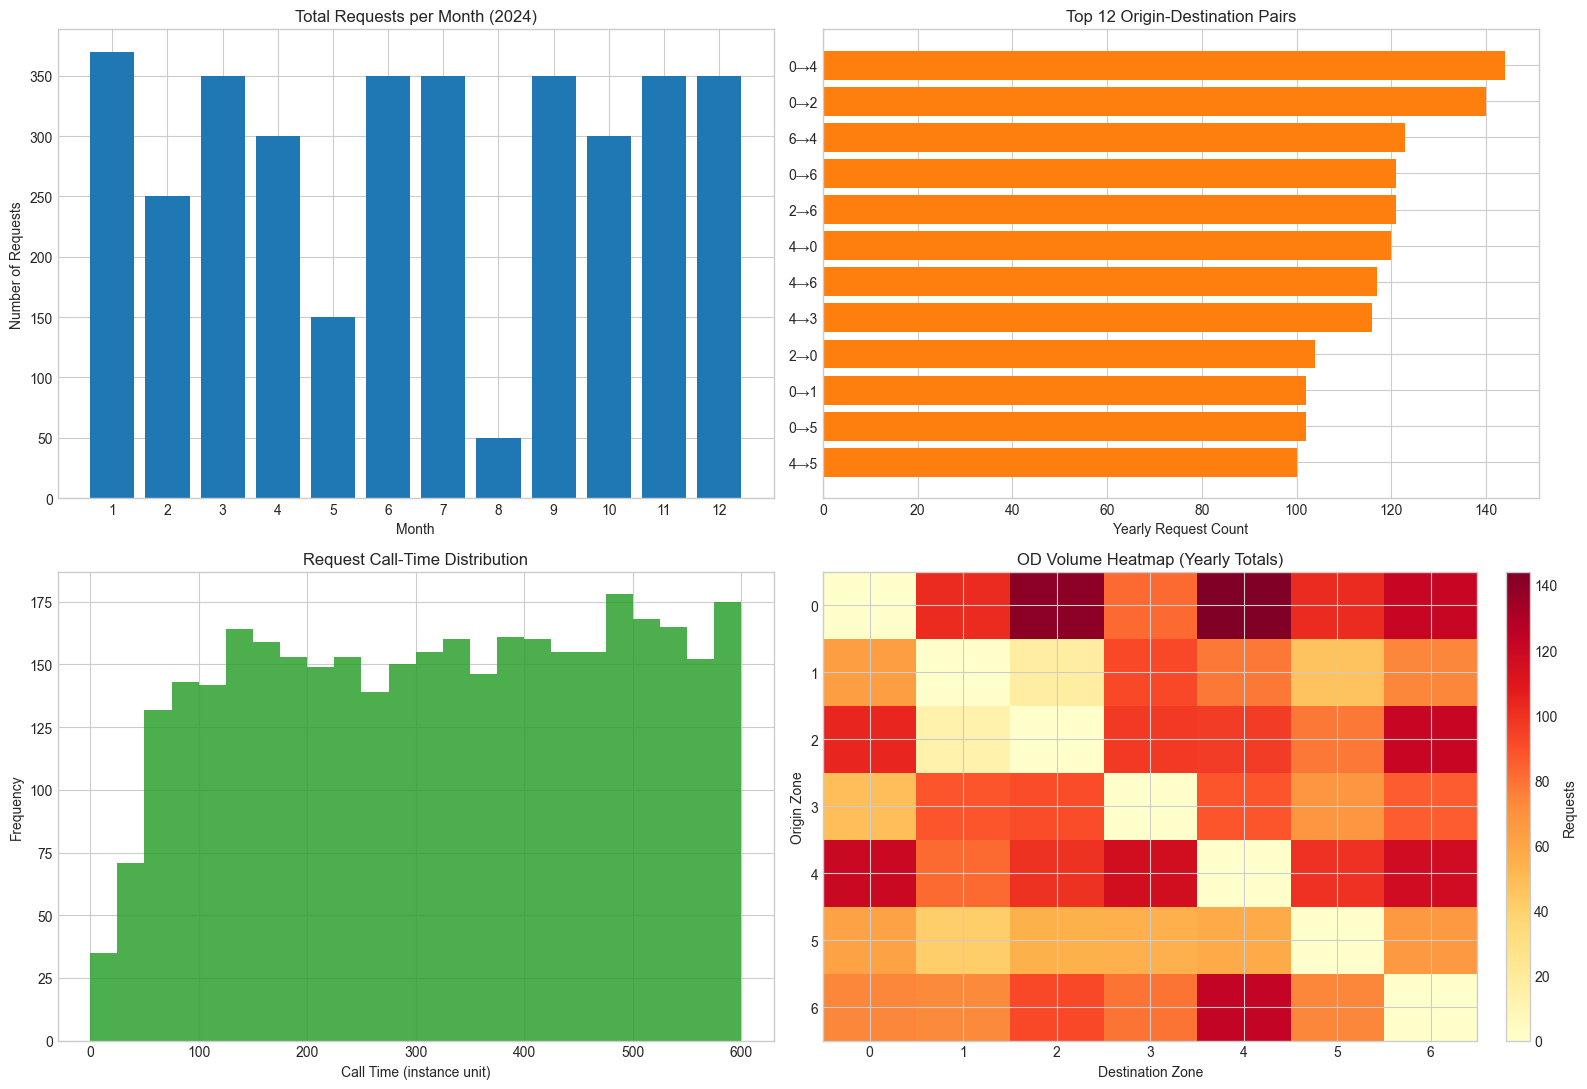

✅ Annual instance analytics completed.
Parsed requests: 3,520
Unique instance files (2024): 31
Inferred zone count: 7
Flow map saved to: plots/instance_yearly_flow_map_2024.html
Charts saved to: plots/instance_yearly_analytics_2024.png


In [9]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium

instances_dir = Path('instances')
instance_pattern = re.compile(r'^instance_(\d+)_(\d+)_(\d{4})-(\d+)-(\d+)$')

records = []
zone_count_candidates = []

for file_path in sorted(instances_dir.iterdir()):
    if not file_path.is_file():
        continue
    match = instance_pattern.match(file_path.name)
    if not match:
        continue

    declared_customers = int(match.group(1))
    declared_horizon = int(match.group(2))
    year = int(match.group(3))
    month = int(match.group(4))
    scenario_id = int(match.group(5))

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as handle:
        raw_lines = [line.strip() for line in handle if line.strip()]

    if not raw_lines:
        continue

    header_tokens = raw_lines[0].split()
    if len(header_tokens) < 3:
        continue

    request_count = int(header_tokens[0])
    zone_count = int(header_tokens[2])
    zone_count_candidates.append(zone_count)

    request_lines = raw_lines[1:1 + request_count]
    for row in request_lines:
        parts = row.split()
        if len(parts) < 4:
            continue

        customer_id = int(parts[0])
        origin_zone = int(parts[1])
        destination_zone = int(parts[2])
        call_time = int(parts[3])

        records.append({
            'instance_file': file_path.name,
            'declared_customers': declared_customers,
            'declared_horizon': declared_horizon,
            'year': year,
            'month': month,
            'scenario_id': scenario_id,
            'customer_id': customer_id,
            'origin_zone': origin_zone,
            'destination_zone': destination_zone,
            'call_time': call_time
        })

requests_df = pd.DataFrame(records)
if requests_df.empty:
    raise ValueError('No requests parsed from instances/. Check file naming or format.')

requests_df = requests_df[requests_df['year'] == 2024].copy()
if requests_df.empty:
    raise ValueError('No 2024 instances found after parsing.')

all_zones = sorted(set(requests_df['origin_zone'].unique()) | set(requests_df['destination_zone'].unique()))
inferred_zone_count = max(zone_count_candidates) if zone_count_candidates else len(all_zones)

yearly_od = (
    requests_df.groupby(['origin_zone', 'destination_zone'])
    .size()
    .rename('trip_count')
    .reset_index()
    .sort_values('trip_count', ascending=False)
)

zone_out = requests_df.groupby('origin_zone').size().rename('outgoing')
zone_in = requests_df.groupby('destination_zone').size().rename('incoming')
zone_stats = pd.concat([zone_out, zone_in], axis=1).fillna(0)
zone_stats.index.name = 'zone'
zone_stats['total_activity'] = zone_stats['outgoing'] + zone_stats['incoming']
zone_stats['net_flow'] = zone_stats['outgoing'] - zone_stats['incoming']
zone_stats = zone_stats.reset_index()

# Build synthetic coordinates for zone-level map (ring layout)
center_lat, center_lon = 41.8781, -87.6298
ring_radius_deg = 0.18
angles = np.linspace(0, 2 * np.pi, len(all_zones), endpoint=False)
zone_to_coord = {
    zone: (
        center_lat + ring_radius_deg * np.sin(angle),
        center_lon + ring_radius_deg * np.cos(angle)
    )
    for zone, angle in zip(all_zones, angles)
}

m_instances_year = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='cartodbpositron')

max_flow = max(1, yearly_od['trip_count'].max())
for _, row in yearly_od.iterrows():
    origin = int(row['origin_zone'])
    destination = int(row['destination_zone'])
    count = int(row['trip_count'])

    if origin not in zone_to_coord or destination not in zone_to_coord:
        continue

    line_width = 1.5 + 8.0 * (count / max_flow)
    popup = (
        f'<b>Flow:</b> Zone {origin} → Zone {destination}<br>'
        f'<b>Total yearly requests:</b> {count}'
    )

    folium.PolyLine(
        locations=[zone_to_coord[origin], zone_to_coord[destination]],
        color='royalblue',
        weight=line_width,
        opacity=0.55,
        popup=popup
    ).add_to(m_instances_year)

max_activity = max(1.0, zone_stats['total_activity'].max())
for _, row in zone_stats.iterrows():
    zone = int(row['zone'])
    outgoing = float(row['outgoing'])
    incoming = float(row['incoming'])
    activity = float(row['total_activity'])
    net_flow = float(row['net_flow'])
    lat, lon = zone_to_coord[zone]

    marker_radius = 6 + 18 * (activity / max_activity)
    marker_color = 'darkgreen' if net_flow >= 0 else 'darkred'

    popup = (
        f'<b>Zone:</b> {zone}<br>'
        f'<b>Outgoing requests:</b> {outgoing:,.0f}<br>'
        f'<b>Incoming requests:</b> {incoming:,.0f}<br>'
        f'<b>Total activity:</b> {activity:,.0f}<br>'
        f'<b>Net flow (out-in):</b> {net_flow:+,.0f}'
    )

    folium.CircleMarker(
        location=[lat, lon],
        radius=marker_radius,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.75,
        weight=2,
        popup=popup
    ).add_to(m_instances_year)

legend_html = """
<div style="
position: fixed;
bottom: 35px;
left: 35px;
width: 360px;
background-color: white;
border: 2px solid #666;
z-index: 9999;
font-size: 13px;
padding: 10px;
">
<b>Annual instance demand map legend</b><br>
- Node size: total zone activity (outgoing + incoming)<br>
- Node color: green = net exporter, red = net importer<br>
- Link width: yearly OD request volume
</div>
"""
m_instances_year.get_root().html.add_child(folium.Element(legend_html))

os.makedirs('plots', exist_ok=True)
instances_map_path = 'plots/instance_yearly_flow_map_2024.html'
m_instances_year.save(instances_map_path)

# Additional charts
monthly_totals = requests_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
top_od = yearly_od.head(12).copy()
top_od['od_pair'] = top_od.apply(
    lambda r: f"{int(r['origin_zone'])}→{int(r['destination_zone'])}", axis=1
)

od_heat = (
    requests_df.groupby(['origin_zone', 'destination_zone'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=all_zones, columns=all_zones, fill_value=0)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Chart 1: monthly volume
axes[0, 0].bar(monthly_totals.index, monthly_totals.values, color='#1f77b4')
axes[0, 0].set_title('Total Requests per Month (2024)')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Requests')
axes[0, 0].set_xticks(range(1, 13))

# Chart 2: top OD pairs
axes[0, 1].barh(top_od['od_pair'], top_od['trip_count'], color='#ff7f0e')
axes[0, 1].set_title('Top 12 Origin-Destination Pairs')
axes[0, 1].set_xlabel('Yearly Request Count')
axes[0, 1].invert_yaxis()

# Chart 3: call-time profile
axes[1, 0].hist(requests_df['call_time'], bins=24, color='#2ca02c', alpha=0.85)
axes[1, 0].set_title('Request Call-Time Distribution')
axes[1, 0].set_xlabel('Call Time (instance unit)')
axes[1, 0].set_ylabel('Frequency')

# Chart 4: OD heatmap
im = axes[1, 1].imshow(od_heat.values, cmap='YlOrRd', aspect='auto')
axes[1, 1].set_title('OD Volume Heatmap (Yearly Totals)')
axes[1, 1].set_xlabel('Destination Zone')
axes[1, 1].set_ylabel('Origin Zone')
axes[1, 1].set_xticks(range(len(all_zones)))
axes[1, 1].set_xticklabels(all_zones)
axes[1, 1].set_yticks(range(len(all_zones)))
axes[1, 1].set_yticklabels(all_zones)
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Requests')

fig.tight_layout()
plots_path = 'plots/instance_yearly_analytics_2024.png'
fig.savefig(plots_path, dpi=300, bbox_inches='tight')
plt.show()

print('✅ Annual instance analytics completed.')
print(f'Parsed requests: {len(requests_df):,}')
print(f'Unique instance files (2024): {requests_df["instance_file"].nunique()}')
print(f'Inferred zone count: {inferred_zone_count}')
print(f'Flow map saved to: {instances_map_path}')
print(f'Charts saved to: {plots_path}')

m_instances_year